## Описание проекта

Проект состоит из двух частей. В первой части  мы приоритизируем  данные о 9 гипотезах по увеличению выручки интернет-магазина из датасета `hypothesis.csv`.

В ходе исследования, мы выполним следующие этапы:

* применим фреймворк ICE для приоритизации гипотез;
* применим фреймворк RICE для приоритизации гипотез;
* проанализурем как изменилась приоритизация гипотез при применении RICE вместо ICE.

Во второй части проекта мы проанализуем результаты проведенного A/B теста, результаты которого описаны в датасетах `orders.csv` и `visitors.csv.`

При анализе результатов A/B теста будут выполнены следующие шаги:

* построение графика кумулятивной выручки по группам;
* построение графика  кумулятивного среднего чека по группам;
* построение графика относительного изменения кумулятивного среднего чека группы B к группе A;
* построение графика  кумулятивного среднего количества заказов на посетителя по группам;
* построение графика относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A;
* построение точечного графика количества заказов по пользователям;
* вычисление 95-й и 99-й перцентили количества заказов на пользователя, определение границы для определения аномальных пользователей;
* построение точечного графикак стоимостей заказов;
* вычисление 95-й и 99-й перцентили стоимости заказов, определение границы для определения аномальных заказов.
* вычисление статистической значимости различий в среднем количестве заказов на посетителя между группами по «сырым» данным;
* вычисление статистической значимости различий в среднем чеке заказа между группами по «сырым» данным;
* вычисление статистической значимости различий в среднем количестве заказов на посетителя между группами по «очищенным» данным;
* вычисление статистической значимости различий в среднем чеке заказа между группами по «очищенным» данным;
* принятие решение по результатам теста.

## Загрузка датасетов и подключение пакетов

В этом блоке мы загрузим все датасеты, а также  все необходимые нам пакеты.

In [1]:
# импортирую пакеты
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt 
import seaborn as sns
import pylab as pl
from pylab import rcParams
import datetime as dt
from datetime import timedelta
import scipy.stats as stats

# выставляем ограничение на показ знаков после запятой
pd.options.display.float_format = '{:,.3f}'.format

In [2]:
# загружаем все три датасета 
try:
    original_hypothesis_info = pd.read_csv('C:/Users/USER/Project_making_decision/hypothesis.csv')
except:
    original_hypothesis_info= pd.read_csv('/datasets/hypothesis.csv')
    
try:
    original_orders_info = pd.read_csv('C:/Users/USER/Project_making_decision/orders.csv')
except:
    original_orders_info= pd.read_csv('/datasets/orders.csv')
    
try:
    original_visitors_info = pd.read_csv('C:/Users/USER/Project_making_decision/visitors.csv')
except:
    original_visitors_info= pd.read_csv('/datasets/visitors.csv')

## Часть 1. Приоретизация гипотез.

Ознакомимся с данными, выведя таблицу на экран.

In [3]:
display(original_hypothesis_info.head(9))  

,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика,...",3,10,8,6
1,"Запустить собственную службу доставки, что сок...",2,5,4,10
2,Добавить блоки рекомендаций товаров на сайт ин...,8,3,7,3
3,"Изменить структура категорий, что увеличит кон...",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы уве...",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине,...",3,2,2,3
6,Показать на главной странице баннеры с актуаль...,5,3,8,3
7,Добавить форму подписки на все основные страни...,10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день...",1,9,9,5


Краткое описание данных:

* `Hypothesis` — краткое описание гипотезы;
* `Reach` — охват пользователей по 10-балльной шкале;
* `Impact` — влияние на пользователей по 10-балльной шкале;
* `Confidence` — уверенность в гипотезе по 10-балльной шкале;
* `Efforts` — затраты ресурсов на проверку гипотезы по 10-балльной шкале. Чем больше значение Efforts, тем дороже проверка гипотезы.

In [4]:
# копия
hypothesis_info = original_hypothesis_info.copy()
hypothesis_info.columns = hypothesis_info.columns.str.lower()

В дальнейшем будем работать с копией базы.

### ICE для приоритизации гипотез

In [5]:
# вычисление ICE
hypothesis_info['ICE']=hypothesis_info['impact']*hypothesis_info['confidence']/hypothesis_info['efforts']

In [6]:
hi_sorted = hypothesis_info.sort_values(by='ICE', ascending=False)
display(hi_sorted)

,hypothesis,reach,impact,confidence,efforts,ICE
8,"Запустить акцию, дающую скидку на товар в день...",1,9,9,5,16.200
0,"Добавить два новых канала привлечения трафика,...",3,10,8,6,13.333
7,Добавить форму подписки на все основные страни...,10,7,8,5,11.200
6,Показать на главной странице баннеры с актуаль...,5,3,8,3,8.000
2,Добавить блоки рекомендаций товаров на сайт ин...,8,3,7,3,7.000
1,"Запустить собственную службу доставки, что сок...",2,5,4,10,2.000
5,"Добавить страницу отзывов клиентов о магазине,...",3,2,2,3,1.333
3,"Изменить структура категорий, что увеличит кон...",8,3,3,8,1.125
4,"Изменить цвет фона главной страницы, чтобы уве...",3,1,1,1,1.000


По методу ICE наиболее высоким приоритетом обладают гипотезы 8, 0 и 7. Выведем заголовки этих гипотез.

In [7]:
for r in hi_sorted.index[:3]:
    print((hi_sorted.loc[r,'hypothesis']))

Запустить акцию, дающую скидку на товар в день рождения
Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей
Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок


### RICE для приоритизации гипотез

In [8]:
# вычисление RICE 
hypothesis_info['RICE'] = hypothesis_info['reach']*hypothesis_info['impact']*hypothesis_info['confidence']\
                          /hypothesis_info['efforts']

In [9]:
hi_sorted = hypothesis_info.sort_values(by='RICE', ascending=False)
display(hi_sorted)

,hypothesis,reach,impact,confidence,efforts,ICE,RICE
7,Добавить форму подписки на все основные страни...,10,7,8,5,11.200,112.000
2,Добавить блоки рекомендаций товаров на сайт ин...,8,3,7,3,7.000,56.000
0,"Добавить два новых канала привлечения трафика,...",3,10,8,6,13.333,40.000
6,Показать на главной странице баннеры с актуаль...,5,3,8,3,8.000,40.000
8,"Запустить акцию, дающую скидку на товар в день...",1,9,9,5,16.200,16.200
3,"Изменить структура категорий, что увеличит кон...",8,3,3,8,1.125,9.000
1,"Запустить собственную службу доставки, что сок...",2,5,4,10,2.000,4.000
5,"Добавить страницу отзывов клиентов о магазине,...",3,2,2,3,1.333,4.000
4,"Изменить цвет фона главной страницы, чтобы уве...",3,1,1,1,1.000,3.000


По методу RICE наиболее высоким приоритетом обладают гипотезы 7, 2 и 0. Выведем их заголовки.

In [10]:
for r in hi_sorted.index[:3]:
    print((hi_sorted.loc[r,'hypothesis']))

Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок
Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа
Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей


Можно заметить, что приритизация гипотез по методу RICE существенно отличается от приоритизации по ICE. Дело в том, что при RICE мы учитываем показател `reach`— охват пользователей по 10-балльной шкале. То есть чем больше пользователей затронет изменение, тем выше приоритет у гипотезы (по сравненинию с методом ICE).

## Анализ результата A/B теста.

### Предобработка данных

Ознакомимся с данными,выведя датасеты на экран.

In [11]:
display(original_orders_info.head())

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


Описание данных датасета `orders.csv`:
* `transactionId` — идентификатор заказа;
* `visitorId` — идентификатор пользователя, совершившего заказ;
* `date` — дата, когда был совершён заказ;
* `revenue` — выручка заказа;
* `group` — группа A/B-теста, в которую попал заказ.

In [12]:
original_orders_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   transactionId  1197 non-null   int64 
 1   visitorId      1197 non-null   int64 
 2   date           1197 non-null   object
 3   revenue        1197 non-null   int64 
 4   group          1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB


In [13]:
# проверим на дубликаты
print(original_orders_info.duplicated().sum())

0


Дубликатов и пропусков нет.

In [14]:
display(original_visitors_info.head())

,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


Описание данных датасета `visitors.csv`:
* `date` — дата;
* `group` — группа A/B-теста;
* `visitors` — количество пользователей в указанную дату в указанной группе A/B-теста

In [15]:
original_visitors_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      62 non-null     object
 1   group     62 non-null     object
 2   visitors  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


In [16]:
# проверим на дубликаты
print(original_visitors_info.duplicated().sum())

0


Пропусков и дубликатов нет.
Создадим копии датафреймов и в дальнейшем будем работать с ними. В копиях приведем данные о датах к типу `datetime` и приведем название колонок к стандартному виду.

In [17]:
# копии
orders_info = original_orders_info.copy()
visitors_info = original_visitors_info.copy()

In [18]:
# переведем данные о дате в формат даты
orders_info['date'] = orders_info['date'].map(
    lambda x: dt.datetime.strptime(x, '%Y-%m-%d'))

visitors_info['date'] = visitors_info['date'].map(
    lambda x: dt.datetime.strptime(x, '%Y-%m-%d'))

In [19]:
# переименуем колонки
orders_info.columns = [x.replace('Id', '_id') for x in orders_info.columns.values]

In [20]:
# проверим что тип изменился
orders_info.info()
visitors_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  1197 non-null   int64         
 1   visitor_id      1197 non-null   int64         
 2   date            1197 non-null   datetime64[ns]
 3   revenue         1197 non-null   int64         
 4   group           1197 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 46.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      62 non-null     datetime64[ns]
 1   group     62 non-null     object        
 2   visitors  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB


### Кумулятривные графики и метрики

Для построения кумулятривных графиков для начала надо cобрать агрегированные кумулятивные по дням данные о заказах.
для этого:
* создадим массив уникальных пар значений дат и групп теста;
* получим агрегированные кумулятивные по дням дням данные о заказах;
* получим агрегированные кумулятивные по дням данные о посетителях; 
* объединим кумулятивные данные в одной таблице;
* построим графики.


In [21]:
# создаем массив уникальных пар значений дат и групп теста
dates_groups = orders_info[['date','group']].drop_duplicates() 
display(dates_groups.head(3))

,date,group
0,2019-08-15,B
2,2019-08-15,A
45,2019-08-16,A


In [22]:
# получаем агрегированные кумулятивные по дням данные о заказах 
orders_aggregated = dates_groups.apply(
    lambda x: orders_info[
        np.logical_and(
            orders_info['date'] <= x['date'], orders_info['group'] == x['group']
        )
    ].agg(
        {
            'date': 'max',
            'group': 'max',
            'transaction_id': 'nunique',
            'visitor_id': 'nunique',
            'revenue': 'sum',
        }
    ),
    axis=1,
).sort_values(by=['date', 'group'])

display(orders_aggregated.head(3))

,date,group,transaction_id,visitor_id,revenue
55,2019-08-01,A,24,20,148579
66,2019-08-01,B,21,20,101217
175,2019-08-02,A,44,38,242401


In [23]:
# получаем агрегированные кумулятивные по дням данные о посетителях 
visitors_aggregated = dates_groups.apply(
    lambda x: visitors_info[
        np.logical_and(
            visitors_info['date'] <= x['date'], visitors_info['group'] == x['group']
        )
    ].agg({'date': 'max', 'group': 'max', 'visitors': 'sum'}),
    axis=1,
).sort_values(by=['date', 'group'])
display(visitors_info.head(3))

,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507


In [24]:
# объединяем кумулятивные данные в одной таблице и присваиваем ее столбцам понятные названия

cumulative_data = orders_aggregated.merge(
    visitors_aggregated, left_on=['date', 'group'], right_on=['date', 'group']
)
cumulative_data.columns = [
    'date',
    'group',
    'orders',
    'buyers',
    'revenue',
    'visitors',
]
display(cumulative_data.head(3))

,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,24,20,148579,719
1,2019-08-01,B,21,20,101217,713
2,2019-08-02,A,44,38,242401,1338


#### График  кумулятивной выручки по группам

Создадим датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе А.

In [25]:
# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе А
cumulative_revenue_A = cumulative_data[cumulative_data['group']=='A'][['date','revenue', 'orders']]
display(cumulative_revenue_A.head(3))

,date,revenue,orders
0,2019-08-01,148579,24
2,2019-08-02,242401,44
4,2019-08-03,354874,68


Создадим датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе B.

In [26]:
# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе B
cumulative_revenue_B = cumulative_data[cumulative_data['group']=='B'][['date','revenue', 'orders']]
display(cumulative_revenue_B.head(3))

,date,revenue,orders
1,2019-08-01,101217,21
3,2019-08-02,266748,45
5,2019-08-03,380996,61


Построим график кумулятивной выручки по группам.

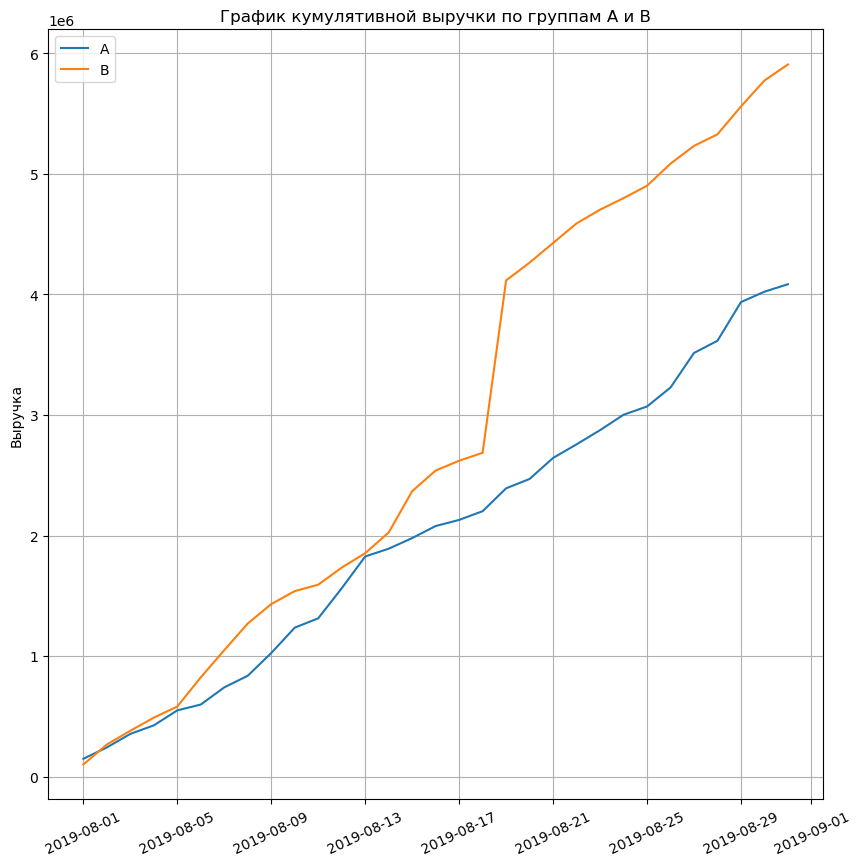

In [27]:
# установим размер и сетку
plt.figure(figsize=(10,10))
plt.grid()

# Строим график выручки группы А
plt.plot(cumulative_revenue_A['date'], cumulative_revenue_A['revenue'], label='A')

# Строим график выручки группы B
plt.plot(cumulative_revenue_B['date'], cumulative_revenue_B['revenue'], label='B')

# легенда и подписи
plt.xticks(rotation=25)
plt.title('График кумулятивной выручки по группам А и В')
plt.ylabel("Выручка")
plt.legend(); 

По графику кумулятивной выручки по группам видно, что выручка гуппы B растет быстрее выручки группы A. Также виден скачкок выручки группы B почти в  2 раза в период 17.08.2019-21.08.2019.

In [28]:
# выведем данные за период скачка
display(cumulative_revenue_B.query('"2019-08-21">=date>="2019-08-16"'))

,date,revenue,orders
31,2019-08-16,2539635,359
33,2019-08-17,2620790,373
35,2019-08-18,2686621,382
37,2019-08-19,4116541,403
39,2019-08-20,4263815,423
41,2019-08-21,4426892,437


Рассмотрев период 17.08.2019-21.08.2019, определили что резский скачок выручки у группы B произошел 19.08.2019. По таблице можно предположить, что прична всплеска в увеличении стоимости заказов, а не в их количестве. Чтобы убедиться в этом построим сводную таблицу и посчитаем матожидание количества заказов и их выручке за весь период, без учета всплеска  и за периоды до и после всплеска.

In [29]:
# Строим сводную таблицу
original_orders_B=orders_info.query('group=="B"')

original_orders_info_B=original_orders_B.pivot_table(
    index='date', values=['transaction_id','revenue'], aggfunc={'transaction_id': "count", 'revenue': "sum"})
original_orders_info_B.columns=['sum_r','count_o']

In [30]:
print(' \n','Матожидания количества заказов:',original_orders_info_B['count_o'].mean(),
      ' \n','Матожидание суммы заказа:',original_orders_info_B['sum_r'].mean())
print(' \n','Матожидания количества заказов без выброса:',
      original_orders_info_B[original_orders_info_B.index!='2019-08-19']['count_o'].mean(),
      ' \n','Матожидание суммы заказа:',
      original_orders_info_B[original_orders_info_B.index!='2019-08-19']['sum_r'].mean())
print(' \n','Матожидания количества заказов после выброса:'
      ,original_orders_info_B[original_orders_info_B.index>'2019-08-19']['count_o'].mean(),
      ' \n','Матожидание суммы заказа после выброса:',
      original_orders_info_B[original_orders_info_B.index>'2019-08-19']['sum_r'].mean())
print(' \n','Матожидания количества заказов до выброса:',
      original_orders_info_B[original_orders_info_B.index<'2019-08-19']['count_o'].mean(),
      ' \n','Матожидание суммы заказа до выброса:',
      original_orders_info_B[original_orders_info_B.index<'2019-08-19']['sum_r'].mean())

 
 Матожидания количества заказов: 20.64516129032258  
 Матожидание суммы заказа: 190572.90322580645
 
 Матожидания количества заказов без выброса: 20.633333333333333  
 Матожидание суммы заказа: 149261.33333333334
 
 Матожидания количества заказов после выброса: 19.75  
 Матожидание суммы заказа после выброса: 149268.25
 
 Матожидания количества заказов до выброса: 21.22222222222222  
 Матожидание суммы заказа до выброса: 149256.72222222222


Действительно, по полученным данным можно сделать вывод, что всплеск выручки 19 августа произошел за счет появления дорогих заказов в выручке, а не за счет роста числа заказов.

#### График кумулятивного среднего чека по группам

Построим графики среднего чека по группам — разделим кумулятивную выручку на кумулятивное число заказов:

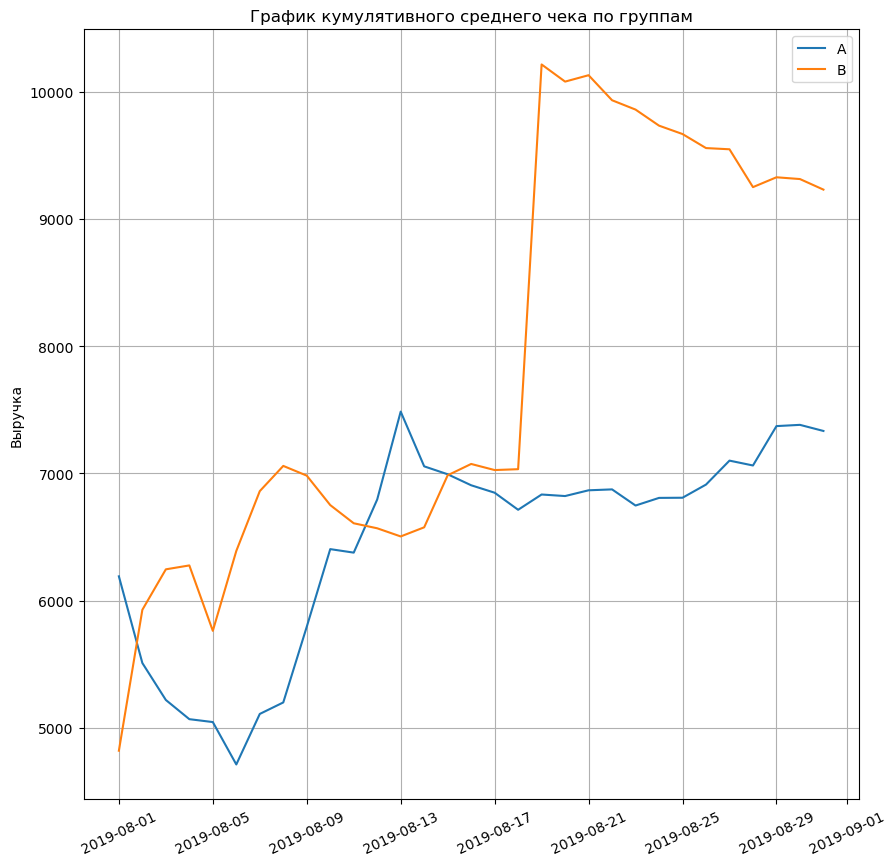

In [31]:
# установим размер и сетку
plt.figure(figsize=(10,10))
plt.grid()

# график кумулятивного среднего чека группы A
plt.plot(cumulative_revenue_A['date'], cumulative_revenue_A['revenue']/cumulative_revenue_A['orders'], label='A')

# график кумулятивного среднего чека группы B
plt.plot(cumulative_revenue_B['date'], cumulative_revenue_B['revenue']/cumulative_revenue_B['orders'], label='B')

# легенда и подписи
plt.xticks(rotation=25)
plt.title('График кумулятивного среднего чека по группам')
plt.ylabel("Выручка")
plt.legend(); 

По графику видно, что кумулятивный средний чек группы A колебался в период до 14-08-2019, а после относительно стабилизировался.

В случае группы B кумулятивный средний чек колебался вплоть 18 авргуста, 19 августа произошел резкий скачек вверх, а после пошел небольшой спад.


#### График относительного изменения кумулятивного среднего чека группы B к группе A

Построим график относительного изменения кумулятивного среднего чека группы B к группе A. Для этого объединим таблицы `cumulative_revenue_A` и `cumulative_revenue_B`.

In [32]:
merged_cumulative_revenue = cumulative_revenue_A.merge(
                            cumulative_revenue_B, left_on='date', right_on='date', how='left', suffixes=['A', 'B'])
merged_cumulative_revenue.columns=['date', 'revenue_A', 'orders_A','revenue_B',  'orders_B']
display(merged_cumulative_revenue.head(5))

,date,revenue_A,orders_A,revenue_B,orders_B
0,2019-08-01,148579,24,101217,21
1,2019-08-02,242401,44,266748,45
2,2019-08-03,354874,68,380996,61
3,2019-08-04,425699,84,489567,78
4,2019-08-05,549917,109,581995,101


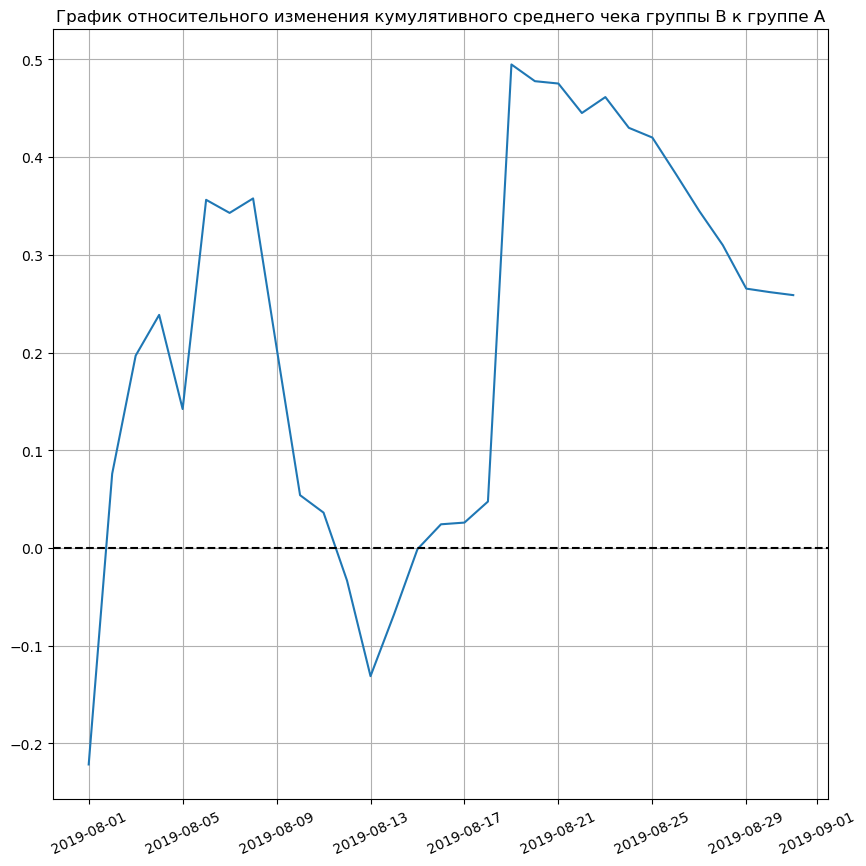

In [33]:
# установим размер и сетку
plt.figure(figsize=(10,10))
plt.grid()

plt.plot(merged_cumulative_revenue['date'],
(merged_cumulative_revenue['revenue_B']/merged_cumulative_revenue['orders_B'])/(merged_cumulative_revenue['revenue_A']/
                                                                          merged_cumulative_revenue['orders_A'])-1)

# добавляем ось X
plt.axhline(y=0, color='black', linestyle='--') 
plt.xticks(rotation=25)
plt.title('График относительного изменения кумулятивного среднего чека группы B к группе A');

Результаты теста значительно и резко менялись в несколько дат. Именно тогда были совершены аномальные заказы.

#### График кумулятивного среднего количества заказов на посетителя по группам

Построим графики среднего чека по группам — разделим кумулятивную выручку на кумулятивное число заказов.

In [34]:
# считаем среднее количество заказов на посетителя
cumulative_data['conversion'] = cumulative_data['orders']/cumulative_data['visitors']
display(cumulative_data.head(3))

,date,group,orders,buyers,revenue,visitors,conversion
0,2019-08-01,A,24,20,148579,719,0.033
1,2019-08-01,B,21,20,101217,713,0.029
2,2019-08-02,A,44,38,242401,1338,0.033


In [35]:
# отделяем данные по группе A
cumulative_data_A = cumulative_data[cumulative_data['group']=='A']
display(cumulative_data_A.head(3))

# отделяем данные по группе B
cumulative_data_B = cumulative_data[cumulative_data['group']=='B']
display(cumulative_data_B.head(3))

,date,group,orders,buyers,revenue,visitors,conversion
0,2019-08-01,A,24,20,148579,719,0.033
2,2019-08-02,A,44,38,242401,1338,0.033
4,2019-08-03,A,68,62,354874,1845,0.037


,date,group,orders,buyers,revenue,visitors,conversion
1,2019-08-01,B,21,20,101217,713,0.029
3,2019-08-02,B,45,43,266748,1294,0.035
5,2019-08-03,B,61,59,380996,1803,0.034


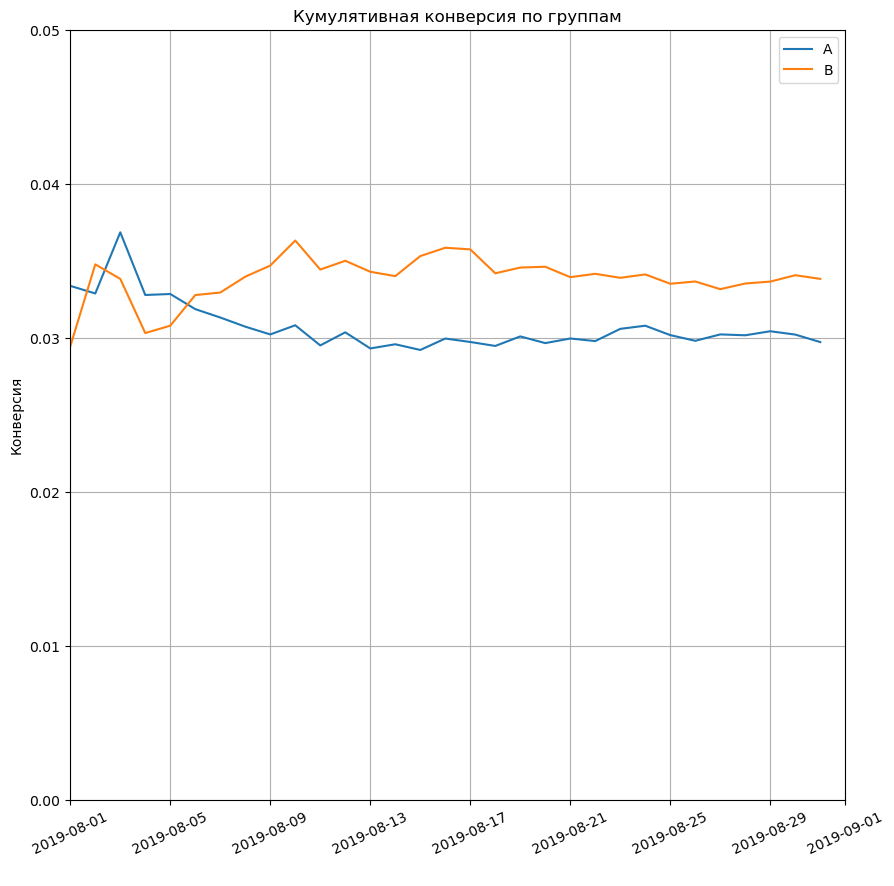

In [36]:
# установим размер и сетку
plt.figure(figsize=(10,10))
plt.grid()

# строим графики
plt.plot(cumulative_data_A['date'], cumulative_data_A['conversion'], label='A')
plt.plot(cumulative_data_B['date'], cumulative_data_B['conversion'], label='B')

plt.title('Кумулятивная конверсия по группам')
plt.xlabel(' ')
plt.ylabel('Конверсия')
plt.xticks(rotation=25)
plt.legend();
# задаем масштаб осей
plt.axis([dt.datetime(2019, 8, 1), dt.datetime(2019, 9, 1), 0, 0.05]);

В начале у обеих группы  кумулятивная конверсия колебалась, но начиная с 9 августа у группы B среднее количество заказов вырвалось вперёд и зафиксировалось, а у группы A — просело, но тоже зафиксировалось.

#### График относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A

Объедините таблицы `cumulative_data_A` и `cumulative_data_B` и построим график относительный прирост конверсии B относительно группы A.

In [37]:
merged_cumulative_conversions = cumulative_data_A[['date','conversion']].merge(
    cumulative_data_B[['date','conversion']], left_on='date', right_on='date', how='left', suffixes=['_A', '_B'])
display(merged_cumulative_conversions.head(3))

,date,conversion_A,conversion_B
0,2019-08-01,0.033,0.029
1,2019-08-02,0.033,0.035
2,2019-08-03,0.037,0.034


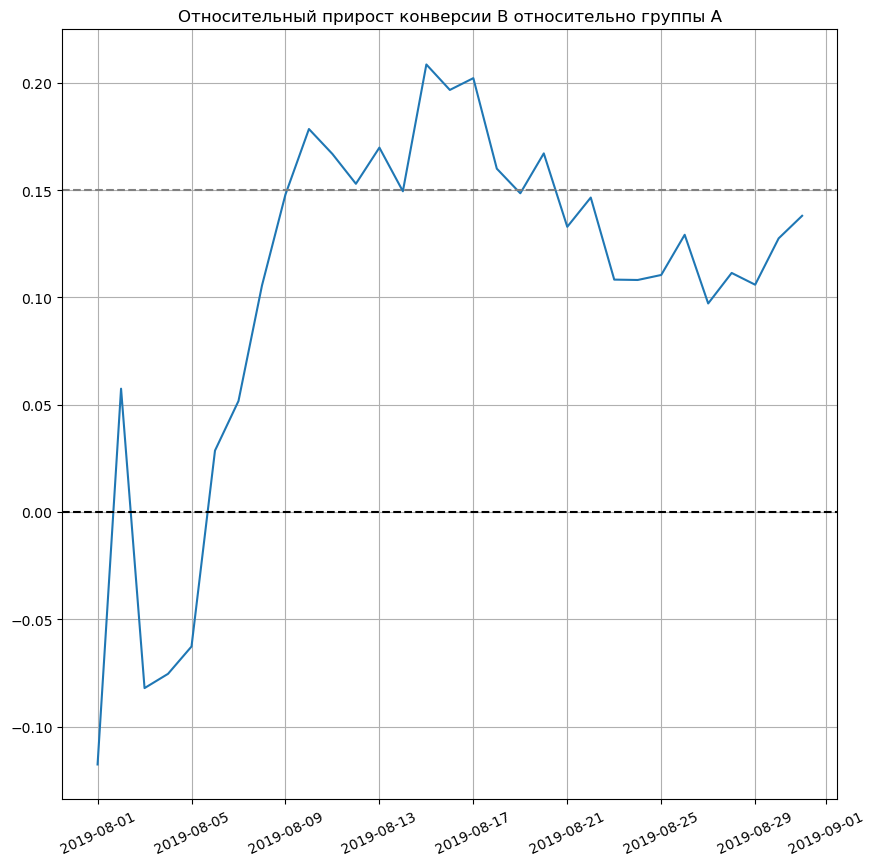

In [38]:
# установим размер и сетку
plt.figure(figsize=(10,10))
plt.grid()

plt.plot(merged_cumulative_conversions['date'],
         merged_cumulative_conversions['conversion_B']/merged_cumulative_conversions['conversion_A']-1, 
         )
plt.xticks(rotation=25)
plt.title('Относительный прирост конверсии B относительно группы A');
# добавляем ось X
plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=0.15, color='grey', linestyle='--');
#plt.axis([dt.datetime(2019, 8, 1), dt.datetime(2019, 9, 1), -0.5, 0.5]);

Начиная с 6 августа B лидирует по метрике: к 9 августа резкий скачок до 15%, потом прирост конверсии находися в коридоре 15-20%,  после 20 августа прирост немного снижается и колеблится в коридоре 10-15%.

### Количество заказов по пользователям

Изучим данные о количестве заказов на пользователя. Для этого посчитаем базовые метрики, построим графики и вычислим перцентили. 

#### Основные метрики и гистограмма

Сгруппируем данные о заказах по пользователям, вычислим остновные метрики и постороим гистограмму.

In [39]:
# Сгруппируем данные
orders_by_users=orders_info.groupby('visitor_id', as_index=False).agg({'transaction_id' : 'nunique'})
orders_by_users.columns=['visitor_id', 'orders']
display(orders_by_users.sort_values(by='orders', ascending=False).head(15))

,visitor_id,orders
1023,4256040402,11
591,2458001652,11
569,2378935119,9
487,2038680547,8
44,199603092,5
744,3062433592,5
55,237748145,5
917,3803269165,5
299,1230306981,5
897,3717692402,5


По таблице видно, что мало пользователей сделало более чем по 3 заказа. Посчитаем основные метрики. 

In [40]:
# основные метрики
orders_by_users['orders'].describe()

count   1,031.000
mean        1.161
std         0.725
min         1.000
25%         1.000
50%         1.000
75%         1.000
max        11.000
Name: orders, dtype: float64

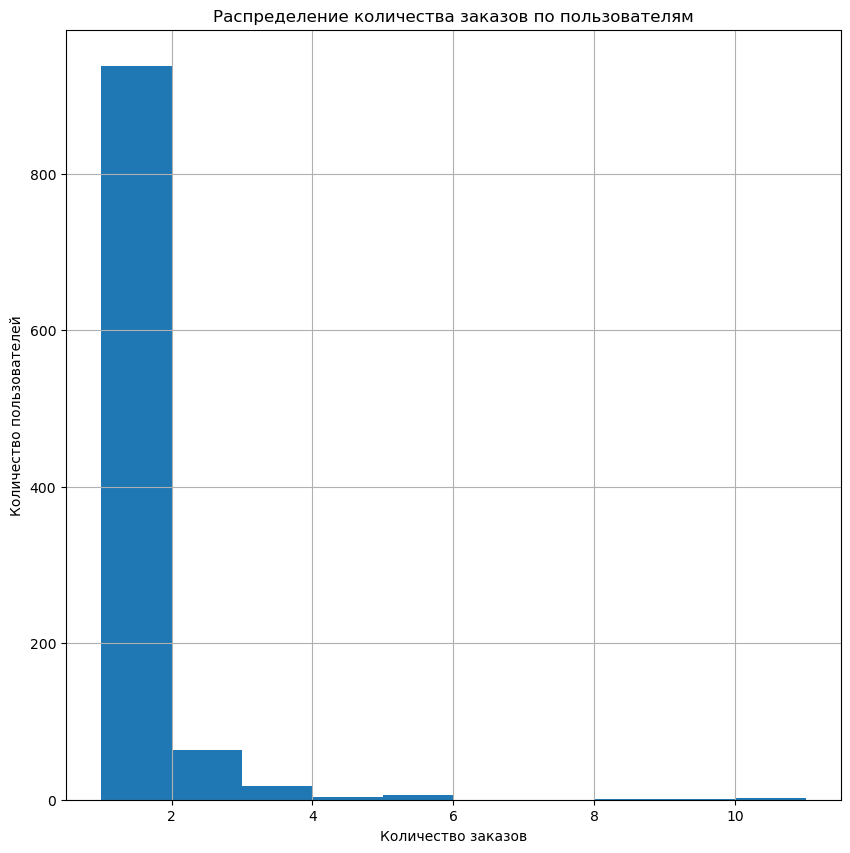

In [41]:
#гистограмма
plt.figure(figsize=(10,10))
plt.grid()
plt.hist(orders_by_users['orders'])
plt.title('Распределение количества заказов по пользователям')
plt.xlabel('Количество заказов')
plt.ylabel('Количество пользователей');

По гистограмме, а также из основных метрик, видно что в основном пользователи делали 1-2 заказа. При этом 75% пользователей сделали 1 заказ. Для большей наглядности построим точечный график.  

#### Точечный график количества заказов по пользователям

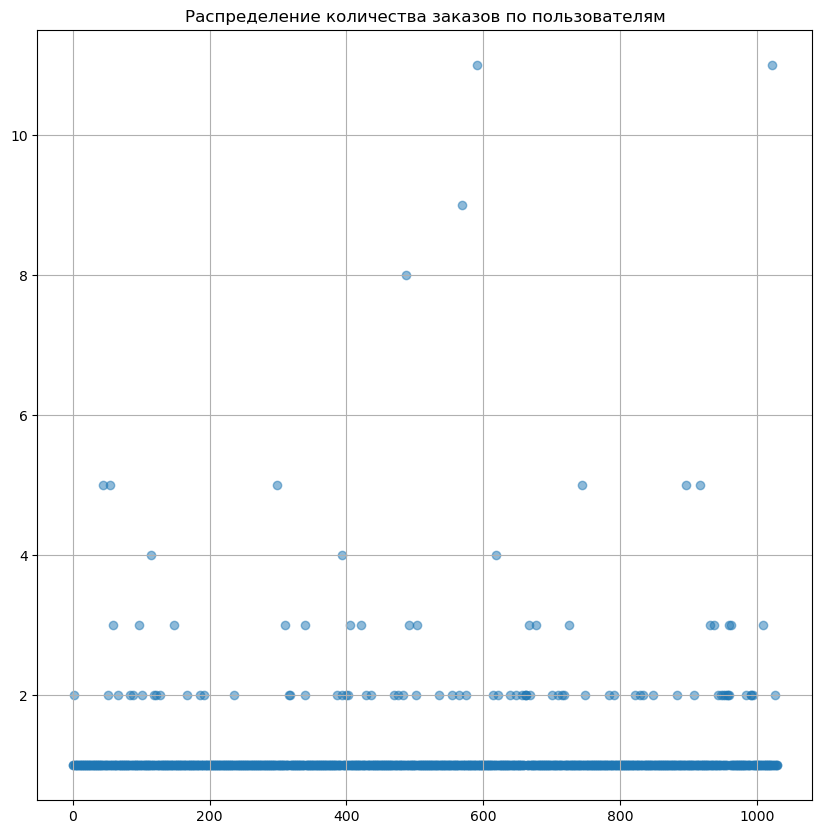

In [42]:
# серия из чисел от 0 до количества наблюдений в ordersByUsers
x_values = pd.Series(range(0, len(orders_by_users)))

plt.figure(figsize=(10,10))
plt.grid()
plt.scatter(x_values, orders_by_users['orders'], alpha=0.5)
plt.title('Распределение количества заказов по пользователям');

В основном пользователи сделали по одному заказу, но также довольно много пользователей совершили 2-3 заказа.

#### Вычисление 95-й и 99-й перцентили количества заказов на пользователя

Выясним, сколько заказов сделало более 5% пользователей, а сколько 1%.

In [43]:
print('95-й и 99-й перцентили количества заказов на пользователя:',np.percentile(orders_by_users['orders'], [ 95, 99])) 

95-й и 99-й перцентили количества заказов на пользователя: [2. 4.]


Не более 5% процентов пользователей совершили 2 заказа и более, и лишь 1% пользователей совершили 4 и более заказов.

По результатам анализа кажется целесообразным установить границу в 4 заказа на пользователя, а остальные данные исключить.

### Стоимость заказов

По аналогии с предыдущим блоком, проанализиурем стоимость заказов.

#### Основные метрики и гистограмма

Вычислим основные метрики и посторим гистограмму

In [44]:
# вычисление
display(orders_info['revenue'].describe());

count       1,197.000
mean        8,348.006
std        39,191.132
min            50.000
25%         1,220.000
50%         2,978.000
75%         8,290.000
max     1,294,500.000
Name: revenue, dtype: float64

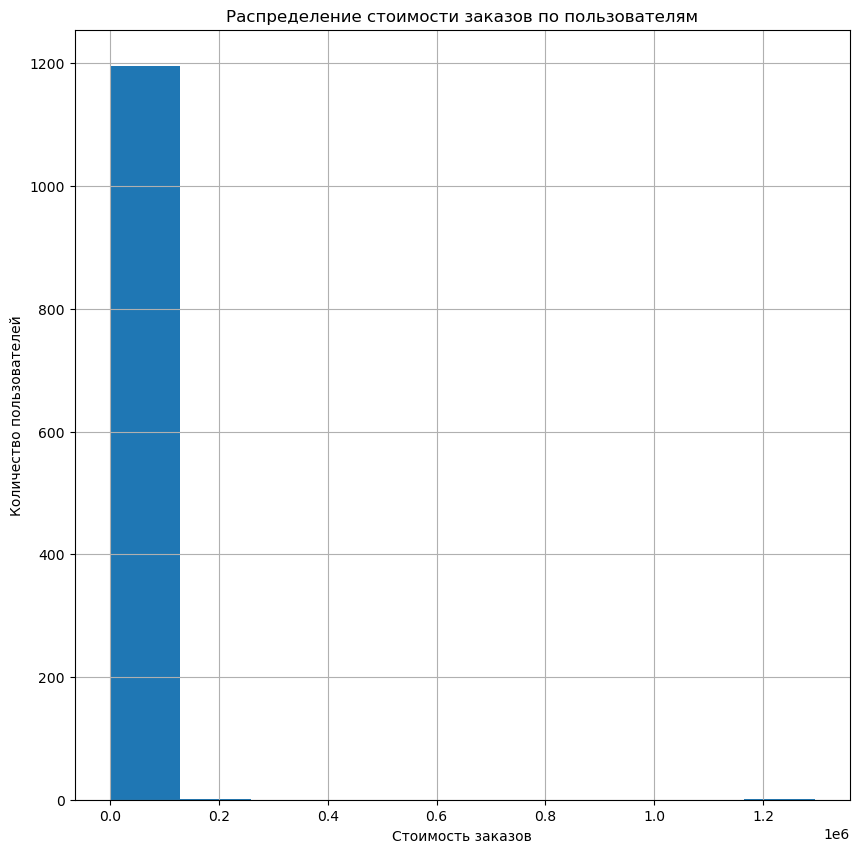

In [45]:
# строим гистограмму
plt.figure(figsize=(10,10))
plt.grid()
plt.hist(orders_info['revenue']) 
plt.title('Распределение стоимости заказов по пользователям')
plt.xlabel('Стоимость заказов')
plt.ylabel('Количество пользователей');

Средняя цена заказа составляет ~ 3350, 75% процентов пользователей сделали заказ на сумму до 8300. При этом есть аномально дорогой заказ — на 1 300 000.

#### Точечный график стоимостей заказов

Посторим точечный график для большей наглядности

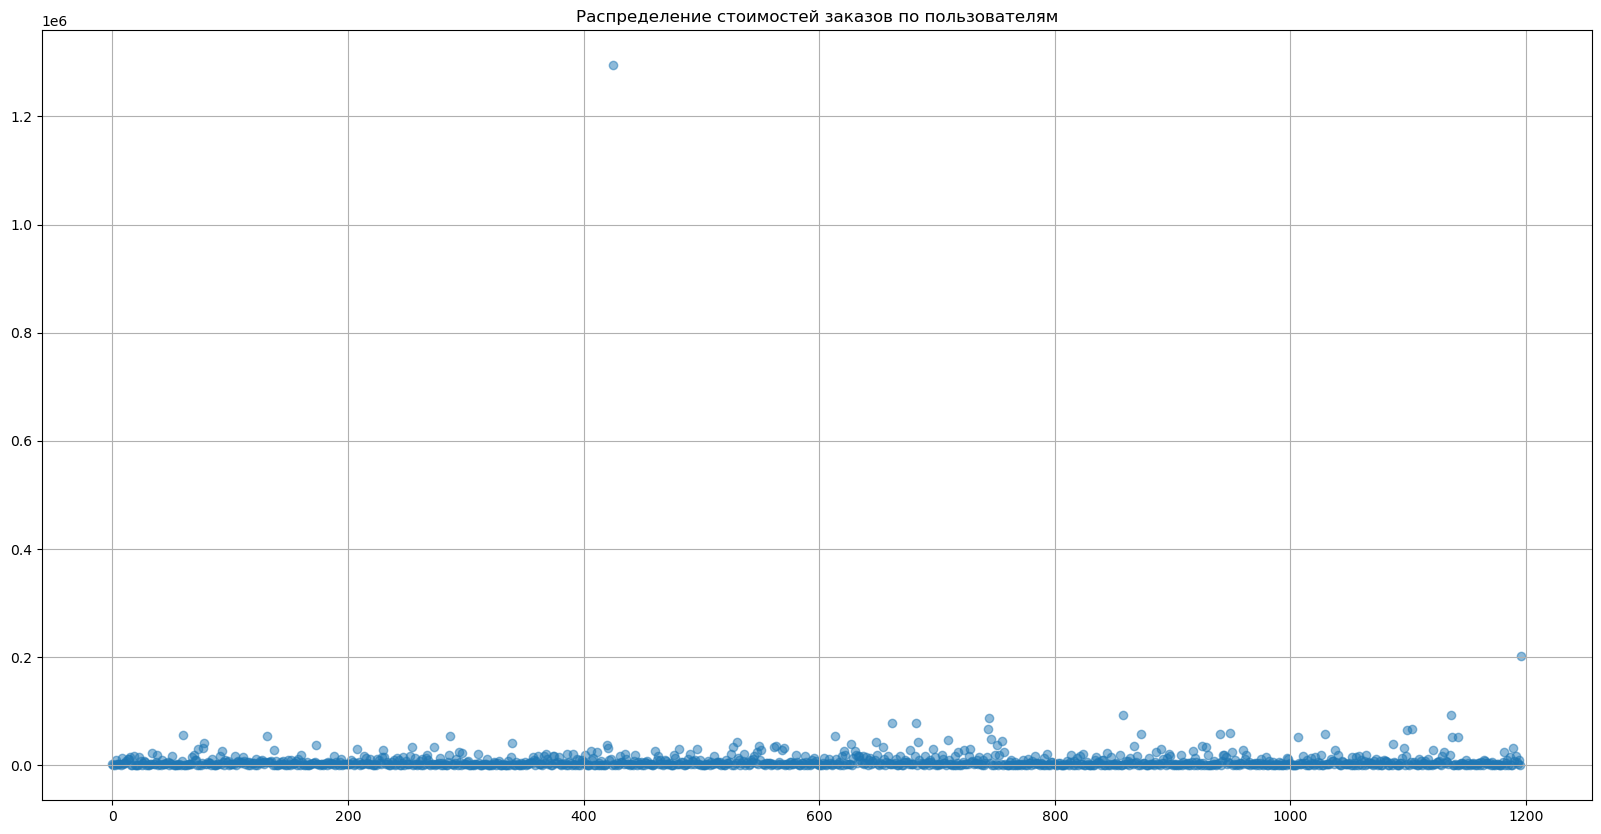

In [46]:
x_values = pd.Series(range(0,len(orders_info)))

# строим точечную диаграмму
plt.figure(figsize=(20,10))
plt.grid()
plt.scatter(x_values, orders_info['revenue'], alpha=0.5)
plt.title('Распределение стоимостей заказов по пользователям');


Такой график не информативен из-за очень дорогого заказа. Рассмотрим график без очень дорогих заказов.

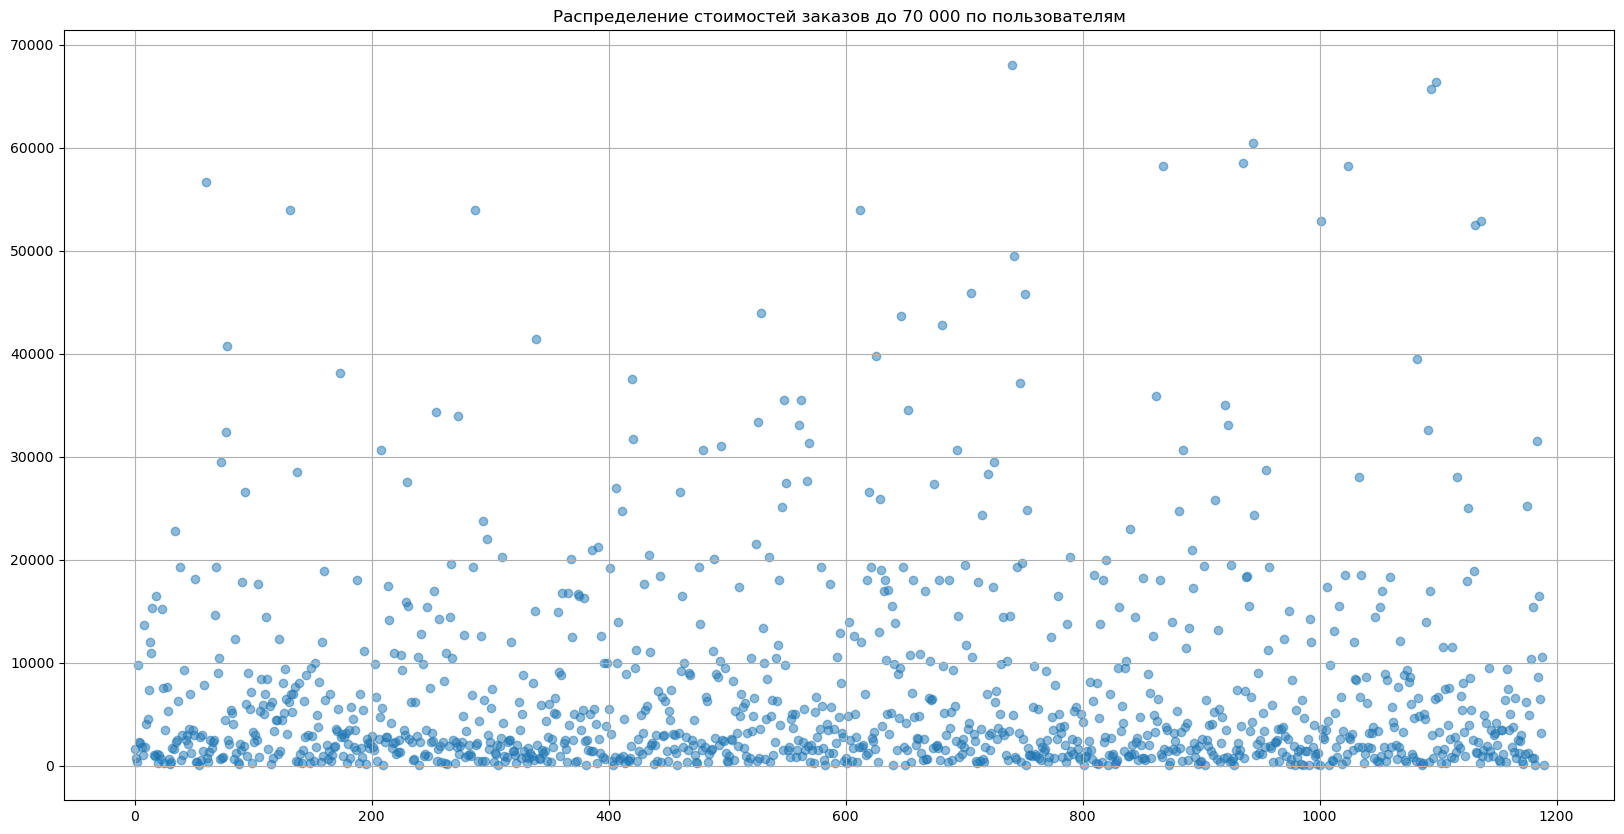

In [47]:
orders_info_without_anomaly_revenue=orders_info.query('revenue<=70000')
x_values = pd.Series(range(0,len(orders_info_without_anomaly_revenue)))
# строим точечную диаграмму
plt.figure(figsize=(20,10))
plt.grid()
plt.scatter(x_values, orders_info_without_anomaly_revenue['revenue'], alpha=0.5)
plt.title('Распределение стоимостей заказов до 70 000 по пользователям');


По графику можно сделать вывод, что большая часть заказов не превышает 10 000, при этом заказов в ценовом диапазоне от 10 000 до 30 000 все еще довльно много. Заказы на сумму более 50 000 уже довольно редки.

#### Вычисление 95-й и 99-й перцентили стоимостей заказов на пользователя

Выясним, какие заказы считать аномально дорогими.

In [48]:
print('95-й и 99-й перцентили количества заказов на пользователя:',np.percentile(orders_info['revenue'], [ 95, 99])) 

95-й и 99-й перцентили количества заказов на пользователя: [28000.  58233.2]


Не более 5% заказов дороже 28 000, и не более 1% дороже 58 233. 

По результатам анализа кажется целесообразным установить границу в 58 233 рубля на пользователя (на уровне 99-й перцентили), а остальные данные исключить.

### Статистическая значимость

Анализ статистической значимости разделим на две части.
В первой части проведем анализ статисчиеской значимости по «сырым» данным, а во второй по очищенным.  

#### Подготовка данных для вычисления статистических  различий  между группами по «сырым» данным

Прежде чем проверять гипотезы, подготовим данные.

Cначала данные по покупателям.

In [49]:
# таблица с покупателями по дням группы A
visitors_A_daily = visitors_info[visitors_info['group'] == 'A'][['date', 'visitors']]
visitors_A_daily.columns = ['date', 'visitors_per_date_A']
display(visitors_A_daily.head(3))

,date,visitors_per_date_A
0,2019-08-01,719
1,2019-08-02,619
2,2019-08-03,507


In [50]:
# таблица с покупателями по дням группы B
visitors_B_daily = visitors_info[visitors_info['group'] == 'B'][['date', 'visitors']]
visitors_B_daily.columns = ['date', 'visitors_per_date_B']
display(visitors_B_daily.head(3))

,date,visitors_per_date_B
31,2019-08-01,713
32,2019-08-02,581
33,2019-08-03,509


In [51]:
# кумулятивная таблица с покупателями по дням группы A
visitors_A_cummulative = visitors_A_daily.apply(
    lambda x: visitors_A_daily[visitors_A_daily['date'] <= x['date']].agg(
        {'date': 'max', 'visitors_per_date_A': 'sum'}
    ),
    axis=1,
)
visitors_A_cummulative.columns = ['date', 'visitors_cummulative_A']
display(visitors_A_cummulative.head(3))

,date,visitors_cummulative_A
0,2019-08-01,719
1,2019-08-02,1338
2,2019-08-03,1845


In [52]:
# кумулятивная таблица с покупателями по дням группы B
visitors_B_cummulative = visitors_B_daily.apply(
    lambda x: visitors_B_daily[visitors_B_daily['date'] <= x['date']].agg(
        {'date': 'max', 'visitors_per_date_B': 'sum'}
    ),
    axis=1,
)
visitors_B_cummulative.columns = ['date', 'visitors_cummulative_B']
display(visitors_B_cummulative.head(3))

,date,visitors_cummulative_B
31,2019-08-01,713
32,2019-08-02,1294
33,2019-08-03,1803


Теперь составим аналогичные таблицы с заказами.

In [53]:
# таблица с заказами по дням группы A
orders_A_daily = (
    orders_info[orders_info['group'] == 'A'][['date', 'transaction_id', 'visitor_id', 'revenue']]
    .groupby('date', as_index=False)
    .agg({'transaction_id': pd.Series.nunique, 'revenue': 'sum'}))
orders_A_daily.columns = ['date', 'orders_daily_A', 'revenue_per_date_A']
display(orders_A_daily.head(3))

,date,orders_daily_A,revenue_per_date_A
0,2019-08-01,24,148579
1,2019-08-02,20,93822
2,2019-08-03,24,112473


In [54]:
# таблица с заказами по дням группы B
orders_B_daily = (
    orders_info[orders_info['group'] == 'B'][['date', 'transaction_id', 'visitor_id', 'revenue']]
    .groupby('date', as_index=False)
    .agg({'transaction_id': pd.Series.nunique, 'revenue': 'sum'}))
orders_B_daily.columns = ['date', 'orders_daily_B', 'revenue_per_date_B']
display(orders_B_daily.head(3))

,date,orders_daily_B,revenue_per_date_B
0,2019-08-01,21,101217
1,2019-08-02,24,165531
2,2019-08-03,16,114248


In [55]:
# кумулятивная таблица с заказами по дням группы A
orders_A_cummulative = orders_A_daily.apply(
    lambda x: orders_A_daily[orders_A_daily['date'] <= x['date']].agg(
        {'date': 'max', 'orders_daily_A': 'sum', 'revenue_per_date_A': 'sum'}
    ),
    axis=1,
).sort_values(by=['date'])
orders_A_cummulative.columns = [
    'date',
    'orders_cummulative_A',
    'revenue_cummulative_A',
]
display(orders_A_cummulative.head(3))

,date,orders_cummulative_A,revenue_cummulative_A
0,2019-08-01,24,148579
1,2019-08-02,44,242401
2,2019-08-03,68,354874


In [56]:
# кумулятивная таблица с заказами по дням группы B
orders_B_cummulative = orders_B_daily.apply(
    lambda x: orders_B_daily[orders_B_daily['date'] <= x['date']].agg(
        {'date': 'max', 'orders_daily_B': 'sum', 'revenue_per_date_B': 'sum'}
    ),
    axis=1,
).sort_values(by=['date'])
orders_B_cummulative.columns = [
    'date',
    'orders_cummulative_B',
    'revenue_cummulative_B',
]
display(orders_B_cummulative.head(3))

,date,orders_cummulative_B,revenue_cummulative_B
0,2019-08-01,21,101217
1,2019-08-02,45,266748
2,2019-08-03,61,380996


Теперь объединим все таблицы в одну 

In [57]:
data_merge = (
    orders_A_daily.merge(
        orders_B_daily, left_on='date', right_on='date', how='left'
    )
    .merge(orders_A_cummulative, left_on='date', right_on='date', how='left')
    .merge(orders_B_cummulative, left_on='date', right_on='date', how='left')
    .merge(visitors_A_daily, left_on='date', right_on='date', how='left')
    .merge(visitors_B_daily, left_on='date', right_on='date', how='left')
    .merge(visitors_A_cummulative, left_on='date', right_on='date', how='left')
    .merge(visitors_B_cummulative, left_on='date', right_on='date', how='left')
)

display(data_merge.head(5))

,date,orders_daily_A,revenue_per_date_A,orders_daily_B,revenue_per_date_B,orders_cummulative_A,revenue_cummulative_A,orders_cummulative_B,revenue_cummulative_B,visitors_per_date_A,visitors_per_date_B,visitors_cummulative_A,visitors_cummulative_B
0,2019-08-01,24,148579,21,101217,24,148579,21,101217,719,713,719,713
1,2019-08-02,20,93822,24,165531,44,242401,45,266748,619,581,1338,1294
2,2019-08-03,24,112473,16,114248,68,354874,61,380996,507,509,1845,1803
3,2019-08-04,16,70825,17,108571,84,425699,78,489567,717,770,2562,2573
4,2019-08-05,25,124218,23,92428,109,549917,101,581995,756,707,3318,3280


Опишем получившуюся таблицу `data_merge`:
* `date` — дата;
* `orders_daily_A` — количество заказов в выбранную дату в группе A;
* `revenue_per_date_A` — суммарная выручка в выбранную дату в группе A;
* `orders_daily_B` — количество заказов в выбранную дату в группе B;
* `revenue_per_date_B` — суммарная выручка в выбранную дату в группе B;
* `orders_cummulative_A` — суммарное число заказов до выбранной даты включительно в группе A;
* `revenue_cummulative_A` — суммарная выручка до выбранной даты включительно в группе A;
* `orders_cummulative_B` — суммарное количество заказов до выбранной даты включительно в группе B;
* `revenue_cummulative_B` — суммарная выручка до выбранной даты включительно в группе B;
* `visitors_per_date_A` — количество пользователей в выбранную дату в группе A;
* `visitors_per_date_B` — количество пользователей в выбранную дату в группе B;
* `visitors_cummulative_A` — количество пользователей до выбранной даты включительно в группе A;
* `visitors_cummulative_A` — количество пользователей до выбранной даты включительно в группе B.

Создадим переменные `orders_by_users_A` и `orders_by_users_B `, где для пользователей, совершивших хотя бы 1 заказ, будет указано число заказов.

In [58]:
# по пользователям A
orders_by_users_A = (
    orders_info[orders_info['group'] == 'A']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique})
)

orders_by_users_A.columns = ['visitor_id', 'orders']

# по пользователям B
orders_by_users_B = (
    orders_info[orders_info['group'] == 'B']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique})
)

orders_by_users_B.columns = ['visitor_id', 'orders']

display(orders_by_users_A.head(3))
display(orders_by_users_B.head(3))

,visitor_id,orders
0,8300375,1
1,11685486,1
2,54447517,1


,visitor_id,orders
0,5114589,1
1,6958315,1
2,8300375,1


Создадим переменные `sample_A` и `sample_B`, в которых пользователям с заказами будет соответствовать число заказов пользователя. А пользователям без заказов — нули. 

In [59]:
# для пользователей А
sample_A = pd.concat([orders_by_users_A['orders'],
                     pd.Series(0, index=np.arange(data_merge['visitors_per_date_A'].sum()
                                                  - len(orders_by_users_A['orders'])), name='orders')],axis=0)
display(sample_A.head())

0    1
1    1
2    1
3    1
4    1
Name: orders, dtype: int64

In [60]:
# Для пользователей B
sample_B = pd.concat([orders_by_users_B['orders'],
                     pd.Series(0, index=np.arange(data_merge['visitors_per_date_B'].sum()
                                                  - len(orders_by_users_B['orders'])), name='orders')],axis=0)
display(sample_B.head())

0    1
1    1
2    1
3    1
4    1
Name: orders, dtype: int64

##### Cтатистическая значимость различий в среднем количестве заказов на посетителя между группами по «сырым» данным

Сформулируем гипотезу:

H0: различий в среднем количестве заказов между группами нет.

H1: различия в среднем между группами есть.

Теперь вычислим p-value тестом Манна-Уитни.

In [61]:
p_value_orders=stats.mannwhitneyu(sample_A, sample_B)[1]
print('P-value:',"{0:.5f}".format(p_value_orders))

print("Относительное различие в среднем между группами: {0:.3%}".format(sample_B.mean() / sample_A.mean()-1))

P-value: 0.01679
Относительное различие в среднем между группами: 13.808%


In [62]:
# уровень значимости 
alpha=0.05
if (p_value_orders < alpha):
        print("Отвергаем нулевую гипотезу: между группами есть разница")
else:
        print("Не получилось отвергнуть нулевую гипотезу, нет оснований считать группы разными")

Отвергаем нулевую гипотезу: между группами есть разница


По "сырым" данным видна разница между группами.
P-value = 0.017 меньше  установленного уровня значимоти $\alpha$ = 0.05. Анализ «сырых данных» сообщает, что в среднем количестве заказов между группами есть статистически значимые различия. Относительный прирост среднего группы B к конверсии группы A равен 13.81%.

##### Статистическая значимость различий в среднем чеке заказа между группами по «сырым» данным

Сформулируем гипотезу:

H0: различий в среднем чеке заказа между группами нет.

H1: различия чеке заказа между группами есть.

Теперь вычислим p-value тестом Манна-Уитни.

In [63]:
p_value_revenue=stats.mannwhitneyu(orders_info[orders_info['group']=='A']['revenue'],
                                  orders_info[orders_info['group']=='B']['revenue'])[1]
print('P-value:',"{0:.5f}".format(p_value_revenue))

print("Относительное различие в чеке между группами: {0:.3%}"
      .format(orders_info[orders_info['group']=='B']['revenue'].mean() / 
                         orders_info[orders_info['group']=='A']['revenue'].mean()-1))

P-value: 0.72929
Относительное различие в чеке между группами: 25.871%


In [64]:
# уровень значимости 
alpha=0.05
if (p_value_revenue < alpha):
        print("Отвергаем нулевую гипотезу: между группами есть разница")
else:
        print("Не получилось отвергнуть нулевую гипотезу, нет оснований считать группы разными")

Не получилось отвергнуть нулевую гипотезу, нет оснований считать группы разными


P-value = 0.73 значительно больше  установленного уровня значимоти $\alpha$ = 0.05. Значит, причин отвергать нулевую гипотезу и считать, что в среднем чеке есть различия, нет. Впрочем, средний чек группы B значительно выше среднего чека группы A

#### Подготовка данных для вычисления статистических  различий  между группами по  «очищенным»  данным

Ранее мы установили границы аномальных данных.
Примем за аномальных пользователей тех кто совершил более 4 заказов (5 и более) и тех, кто сделал заказы дороже 58 233.

In [65]:
# пользователи с большим количесвом заказов
users_with_many_orders =  pd.concat(
    [orders_by_users_A[orders_by_users_A['orders'] > 4]['visitor_id'],
     orders_by_users_B[orders_by_users_B['orders'] > 4]['visitor_id'],
    ],
    axis=0,)
display(users_with_many_orders)

227    2038680547
278    2458001652
499    4256040402
326    2378935119
340    2458001652
Name: visitor_id, dtype: int64

In [66]:
# пользователи с дорогими заказами
users_with_expensive_orders = orders_info[orders_info['revenue'] > 58233]['visitor_id']
display(users_with_expensive_orders.head(3))

425    1920142716
662    4266935830
682    4266935830
Name: visitor_id, dtype: int64

Теперь объединим их в одну таблицу.

In [67]:
anomaly_users =  pd.concat([users_with_many_orders, users_with_expensive_orders], axis=0).drop_duplicates().sort_values()
display(anomaly_users.head())
print(anomaly_users.shape[0])

1099     148427295
949      887908475
744      888512513
1103    1164614297
1136    1307669133
Name: visitor_id, dtype: int64

15


Создадим переменные `sample_A_filtered` и `sample_B_filtered`, в которых сохраним очищенные данные о заказах — не включая аномальных пользователей.

In [68]:
# группа A
sample_A_filtered = pd.concat(
    [orders_by_users_A[np.logical_not(orders_by_users_A['visitor_id'].isin(anomaly_users))]['orders'],
    pd.Series(0, index=np.arange(
                data_merge['visitors_per_date_A'].sum() - len(orders_by_users_A['orders']) ), name='orders', ),],axis=0,)
display(sample_A_filtered.head(3))

0    1
1    1
2    1
Name: orders, dtype: int64

In [69]:
# группа B
sample_B_filtered = pd.concat(
    [orders_by_users_B[np.logical_not(orders_by_users_B['visitor_id'].isin(anomaly_users))]['orders'],
    pd.Series(0, index=np.arange(
                data_merge['visitors_per_date_B'].sum() - len(orders_by_users_B['orders']) ), name='orders', ),],axis=0,)
display(sample_B_filtered.head(3))

0    1
1    1
2    1
Name: orders, dtype: int64

##### Статистическая значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным

Сформулируем гипотезу:

H0: различий в среднем количестве заказов между группами нет.

H1: различия в среднем количестве заказов между группами есть.

Теперь вычислим p-value тестом Манна-Уитни.

In [70]:
p_value_orders_filtered=stats.mannwhitneyu(sample_A_filtered, sample_B_filtered)[1]
print('P-value:',"{0:.5f}".format(p_value_orders_filtered))

print("Относительное различие в среднем между группами: {0:.3%}".format(sample_B_filtered.mean() /
                                                                        sample_A_filtered.mean()-1))

P-value: 0.01438
Относительное различие в среднем между группами: 15.331%


In [71]:
# уровень значимости 
alpha=0.05
if (p_value_orders_filtered < alpha):
        print("Отвергаем нулевую гипотезу: между группами есть разница")
else:
        print("Не получилось отвергнуть нулевую гипотезу, нет оснований считать группы разными")

Отвергаем нулевую гипотезу: между группами есть разница


P-value = 0.014 меньше  установленного уровня значимоти $\alpha$ = 0.05. Анализ «очищенных» данных сообщает, что в среднем количестве заказов между группами есть статистически значимые различия. Относительный прирост среднего группы B к конверсии группы A равен 15.3%.

#### Статистическая значимость различий в среднем чеке заказа между группами по «очищенным» данным

Сформулируем гипотезу:

H0: различий в среднем чеке заказа между группами нет.

H1: различия чеке заказа между группами есть.

Теперь вычислим p-value тестом Манна-Уитни.

In [72]:
sample_A_revenue_filtered= orders_info[(orders_info['group']=='A') 
                                        & np.logical_not(orders_info['visitor_id'].isin(anomaly_users))]['revenue']
sample_B_revenue_filtered= orders_info[(orders_info['group']=='B') 
                                        & np.logical_not(orders_info['visitor_id'].isin(anomaly_users))]['revenue']

In [73]:
p_value_revenue_filtered=stats.mannwhitneyu( sample_A_revenue_filtered
                                           , sample_B_revenue_filtered)[1]
print('P-value:',"{0:.5f}".format(p_value_revenue_filtered))

print("Относительное различие в среднем между группами: {0:.3%}".format (sample_B_revenue_filtered.mean() /
                                                                        sample_A_revenue_filtered.mean()-1))

P-value: 0.85091
Относительное различие в среднем между группами: -0.575%


In [74]:
# уровень значимости 
alpha=0.05
if (p_value_revenue_filtered < alpha):
        print("Отвергаем нулевую гипотезу: между группами есть разница")
else:
        print("Не получилось отвергнуть нулевую гипотезу, нет оснований считать группы разными")

Не получилось отвергнуть нулевую гипотезу, нет оснований считать группы разными


P-value = 0.85 значительно больше  установленного уровня значимоти $\alpha$ = 0.05. Значит, причин отвергать нулевую гипотезу и считать, что в среднем чеке есть различия, нет. Разницы между средними чеками группы B и A практически нет.

## Выводы

###  Приоритизация гипотез 

Из списка гипотез, предоставленных отделом маркетинга для увеличения выручки наиболее перспективно выгядят следующие гипотезы:
* Запустить акцию, дающую скидку на товар в день рождения.
* Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей.
* Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок.

Однако, если в приоритизации учитывать охват пользоваталей, то в таком случае приоритет несколько меняется:
* Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок
* Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа
* Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей

### Анализ результата A/B теста.

* По графикам кумулятивной выручки по группам и кумулятивного среднего чека видно, что в данных присутсвуют аномальные значения. Несмотря на это, динамика группы B выглядит лучше динамики группы A.
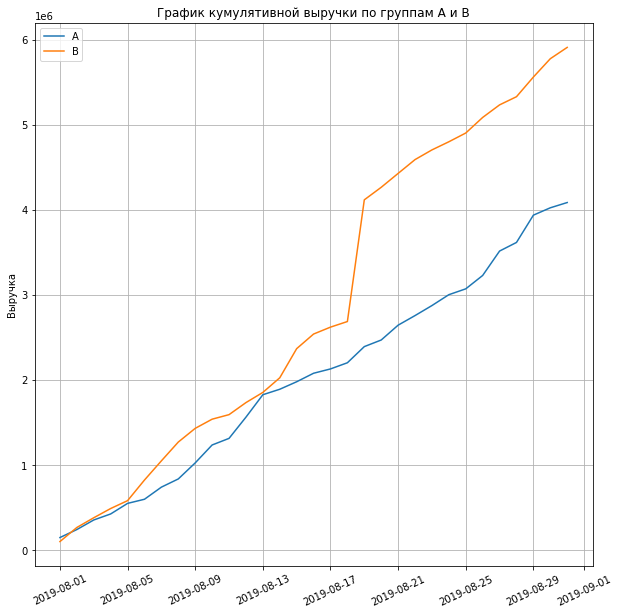
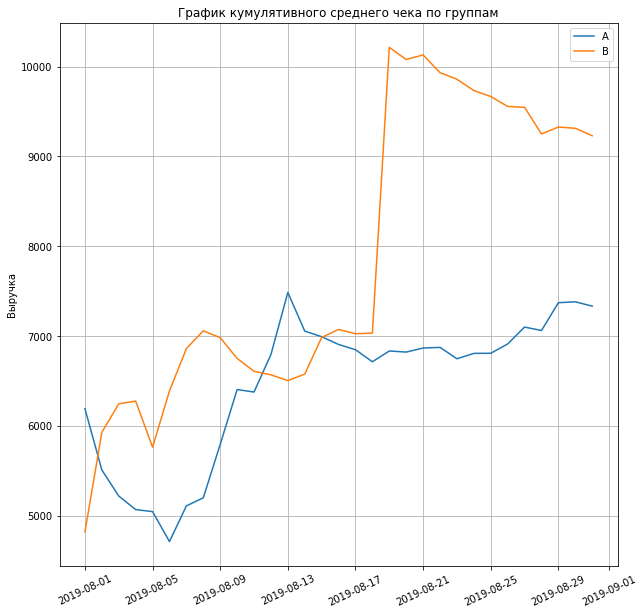

* Кумулятивная конверсия к концу рассматриваемого периода стабилизировалась в обеих группах. При этом конверсия группы B выше чем группы A.
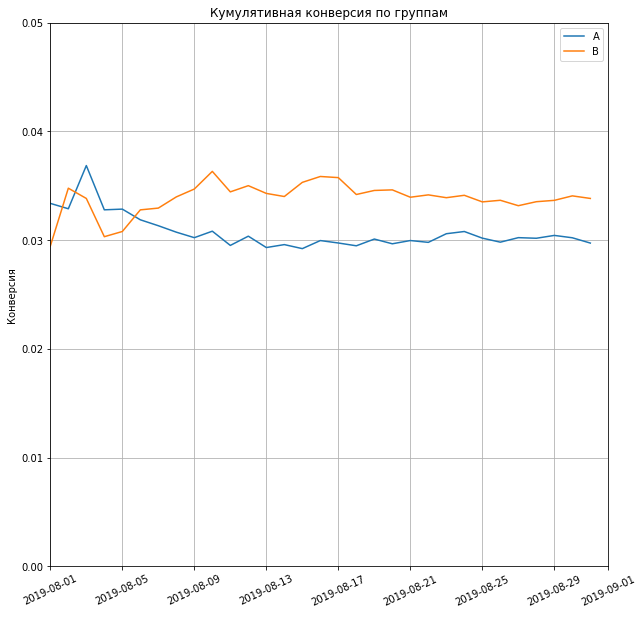

* Для очистки данных от аномальных пользователей установили границу на уровне 99-перцентиля стоимости заказа и количества заказов. Таким образом отсекли пользователей, совершивших более 4-х заказов или сделавших заказы на сумму более 58233. 

* Есть статистически значимое различие по конверсии между группами как по «сырым», так и по данным после фильтрации аномалий. Конверсия группы В выше, чем в А, на 13-15%;
* Нет статистически значимого различия по по среднему чеку между группами ни по «сырым», ни по данным после фильтрации аномалий.

По итогам анализа А/В теста рекомендованно:
* тест остановить;
* зафиксировать победу группы B.